# 🏅 Análise de Medalhas Olímpicas por País (1896-2024)

## 👥 Autores
Carlos Lavor Neto & Alexandro Pantoja - UEA

## 📋 Análise Parte 1
- **1.1**: 3 tabelas ordenadas (Verão, Inverno, Total)
- **1.2**: 3 gráficos Top 50 países
- Dados integrados: 1896-2022 (histórico) + Paris 2024


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

print("✅ Bibliotecas importadas!")

✅ Bibliotecas importadas!


In [16]:
BASE_PATH = Path('..')
RAW_PATH = BASE_PATH / 'raw'
BRONZE_PATH = BASE_PATH / 'bronze'
GOLD_PATH = BASE_PATH / 'gold'
OUTPUTS_PATH = BASE_PATH / 'outputs'

print("✅ Caminhos configurados")

✅ Caminhos configurados


---
## 1. Carregamento e Integração de Dados

In [17]:
# Carregar dados históricos (1896-2022, inclui Tóquio 2020 e Pequim 2022)
df_hist = pd.read_csv(RAW_PATH / 'Olympics_1896_2022' / 'world_olympedia_olympics_game_medal_tally.csv')
print(f"📊 Dados históricos: {len(df_hist):,} registros")
print(f"   Período: {df_hist['year'].min()}-{df_hist['year'].max()}")

# Adicionar coluna season
df_hist['season'] = df_hist['edition'].apply(lambda x: 'Winter' if 'Winter' in str(x) else 'Summer')

# TRATAMENTO ESPECIAL: 1956 Equestrian (Stockholm)
# Os Jogos Equestres de 1956 foram realizados em Estocolmo devido à quarentena australiana
# Vamos consolidar com os Jogos de Melbourne para cada país
equestrian_1956 = df_hist[df_hist['edition'] == '1956 Equestrian'].copy()
if len(equestrian_1956) > 0:
    print(f"\n🐴 Consolidando 1956 Equestrian (Stockholm) com 1956 Summer (Melbourne)...")
    
    # Para cada país nos Jogos Equestres
    for idx, row in equestrian_1956.iterrows():
        noc = row['country_noc']
        # Verificar se o país já tem entrada nos Jogos de Verão de 1956
        summer_1956_idx = df_hist[(df_hist['year'] == 1956) & 
                                   (df_hist['country_noc'] == noc) & 
                                   (df_hist['edition'] == '1956 Summer Olympics')].index
        
        if len(summer_1956_idx) > 0:
            # Somar as medalhas equestres às medalhas dos Jogos de Verão
            df_hist.loc[summer_1956_idx[0], 'gold'] += row['gold']
            df_hist.loc[summer_1956_idx[0], 'silver'] += row['silver']
            df_hist.loc[summer_1956_idx[0], 'bronze'] += row['bronze']
            df_hist.loc[summer_1956_idx[0], 'total'] += row['total']
        else:
            # Converter a entrada equestre para Summer Olympics
            df_hist.loc[idx, 'edition'] = '1956 Summer Olympics'
            df_hist.loc[idx, 'edition_id'] = 14
    
    # Remover as entradas duplicadas (mantendo apenas as consolidadas)
    df_hist = df_hist[df_hist['edition'] != '1956 Equestrian'].reset_index(drop=True)
    print(f"   ✅ Consolidação concluída")

# VERIFICAR E REMOVER DUPLICATAS no histórico
duplicates = df_hist.duplicated(subset=['year', 'country_noc', 'season'], keep='first')
if duplicates.any():
    print(f"\n⚠️  Removendo {duplicates.sum()} registros duplicados do histórico")
    print(f"   Países afetados: {', '.join(df_hist[duplicates]['country_noc'].unique())}")
    df_hist = df_hist[~duplicates].copy()

# Carregar Paris 2024
df_paris = pd.read_csv(RAW_PATH / 'Olympics_Paris2024' / 'medals_total.csv')
print(f"\n📊 Dados Paris 2024: {len(df_paris):,} registros")

# Preparar Paris 2024 para integração
df_paris_prep = df_paris.rename(columns={
    'country_code': 'country_noc',
    'Gold Medal': 'gold',
    'Silver Medal': 'silver',
    'Bronze Medal': 'bronze',
    'Total': 'total'
}).copy()

df_paris_prep['year'] = 2024
df_paris_prep['edition'] = '2024 Summer Olympics'
df_paris_prep['edition_id'] = 999
df_paris_prep['season'] = 'Summer'

# VERIFICAR se Paris 2024 já existe no histórico
existing_2024 = df_hist[df_hist['year'] == 2024]
if len(existing_2024) > 0:
    print(f"\n⚠️  Dados de 2024 já existem no histórico! Removendo {len(existing_2024)} registros...")
    df_hist = df_hist[df_hist['year'] != 2024].copy()

# Integrar: histórico + Paris 2024
df_integrated = pd.concat([df_hist, df_paris_prep], ignore_index=True)

# Verificar duplicatas no resultado final
final_dupes = df_integrated.duplicated(subset=['year', 'country_noc', 'season'], keep='first')
if final_dupes.any():
    print(f"\n⚠️  ERRO: Ainda existem {final_dupes.sum()} duplicatas após integração!")
    print("   Removendo duplicatas...")
    df_integrated = df_integrated[~final_dupes].copy()

# Salvar
df_integrated.to_parquet(BRONZE_PATH / 'medals_integrated_1896_2024.parquet', index=False)

print(f"\n✅ Dados integrados: {len(df_integrated):,} registros")
print(f"   Anos: {df_integrated['year'].min()}-{df_integrated['year'].max()}")
print(f"   Países únicos: {df_integrated['country_noc'].nunique()}")

# Estatísticas gerais
total_summer = df_integrated[df_integrated['season']=='Summer']
total_winter = df_integrated[df_integrated['season']=='Winter']
print(f"\n📈 Estatísticas gerais:")
print(f"   Jogos de Verão: {len(total_summer)} participações de países")
print(f"   Jogos de Inverno: {len(total_winter)} participações de países")
print(f"   Total de medalhas distribuídas: {int(df_integrated['total'].sum()):,}")

📊 Dados históricos: 1,807 registros
   Período: 1896-2022

🐴 Consolidando 1956 Equestrian (Stockholm) com 1956 Summer (Melbourne)...
   ✅ Consolidação concluída

📊 Dados Paris 2024: 92 registros

✅ Dados integrados: 1,893 registros
   Anos: 1896-2024
   Países únicos: 160

📈 Estatísticas gerais:
   Jogos de Verão: 1454 participações de países
   Jogos de Inverno: 439 participações de países
   Total de medalhas distribuídas: 21,697


---
## 2. Análise 1.1 - Tabelas Consolidadas

Gerando 3 tabelas ordenadas por total de medalhas (decrescente).

In [18]:
def create_consolidated_table(df, season_filter=None, name=''):
    """Cria tabela consolidada de medalhas"""
    
    # Filtrar por season se necessário
    if season_filter:
        df_filtered = df[df['season'] == season_filter].copy()
    else:
        df_filtered = df.copy()
    
    # Agrupar por país
    result = df_filtered.groupby('country_noc', as_index=False).agg({
        'gold': 'sum',
        'silver': 'sum',
        'bronze': 'sum',
        'total': 'sum'
    })
    
    # Ordenar por total (decrescente)
    result = result.sort_values('total', ascending=False).reset_index(drop=True)
    
    # Adicionar rank
    result.insert(0, 'rank', range(1, len(result) + 1))
    
    return result

print("="*100)
print("GERANDO TABELAS CONSOLIDADAS")
print("="*100)

# 1. JOGOS DE VERÃO
print("\n📋 1.1.1 - MEDALHAS JOGOS DE VERÃO")
df_summer = create_consolidated_table(df_integrated, 'Summer', 'summer')
print(f"Total de países: {len(df_summer)}")
print("\nTop 10:")
print(df_summer.head(10).to_string(index=False))

# Salvar
df_summer.to_csv(OUTPUTS_PATH / 'tables' / 'medals_summer.csv', index=False)
df_summer.to_parquet(GOLD_PATH / 'medals_summer.parquet', index=False)

# 2. JOGOS DE INVERNO  
print("\n\n📋 1.1.2 - MEDALHAS JOGOS DE INVERNO")
df_winter = create_consolidated_table(df_integrated, 'Winter', 'winter')
print(f"Total de países: {len(df_winter)}")
print("\nTop 10:")
print(df_winter.head(10).to_string(index=False))

# Salvar
df_winter.to_csv(OUTPUTS_PATH / 'tables' / 'medals_winter.csv', index=False)
df_winter.to_parquet(GOLD_PATH / 'medals_winter.parquet', index=False)

# 3. TOTAL GERAL
print("\n\n📋 1.1.3 - MEDALHAS TOTAL GERAL")
df_total = create_consolidated_table(df_integrated, None, 'total')
print(f"Total de países: {len(df_total)}")
print("\nTop 10:")
print(df_total.head(10).to_string(index=False))

# Salvar
df_total.to_csv(OUTPUTS_PATH / 'tables' / 'medals_total.csv', index=False)
df_total.to_parquet(GOLD_PATH / 'medals_total.parquet', index=False)

print("\n" + "="*100)
print("✅ 3 tabelas geradas e salvas!")
print("="*100)

GERANDO TABELAS CONSOLIDADAS

📋 1.1.1 - MEDALHAS JOGOS DE VERÃO
Total de países: 159

Top 10:
 rank country_noc  gold  silver  bronze  total
    1         USA  1122     891     792   2805
    2         GBR   314     356     349   1019
    3         URS   395     319     296   1010
    4         FRA   262     292     323    877
    5         GER   255     286     304    845
    6         CHN   303     226     198    727
    7         ITA   241     214     233    688
    8         AUS   180     189     228    597
    9         JPN   189     162     193    544
   10         HUN   190     168     186    544


📋 1.1.2 - MEDALHAS JOGOS DE INVERNO
Total de países: 46

Top 10:
 rank country_noc  gold  silver  bronze  total
    1         NOR   148     134     123    405
    2         USA   113     122      95    330
    3         GER   112     104      70    286
    4         AUT    71      88      91    250
    5         CAN    77      72      76    225
    6         URS    78      57      59 

---
## 3. Análise 1.2 - Gráficos Top 50

Gerando 3 gráficos de barras horizontais com Top 50 países.

GERANDO GRÁFICOS TOP 50

📊 Gráfico 1: Jogos de Verão...


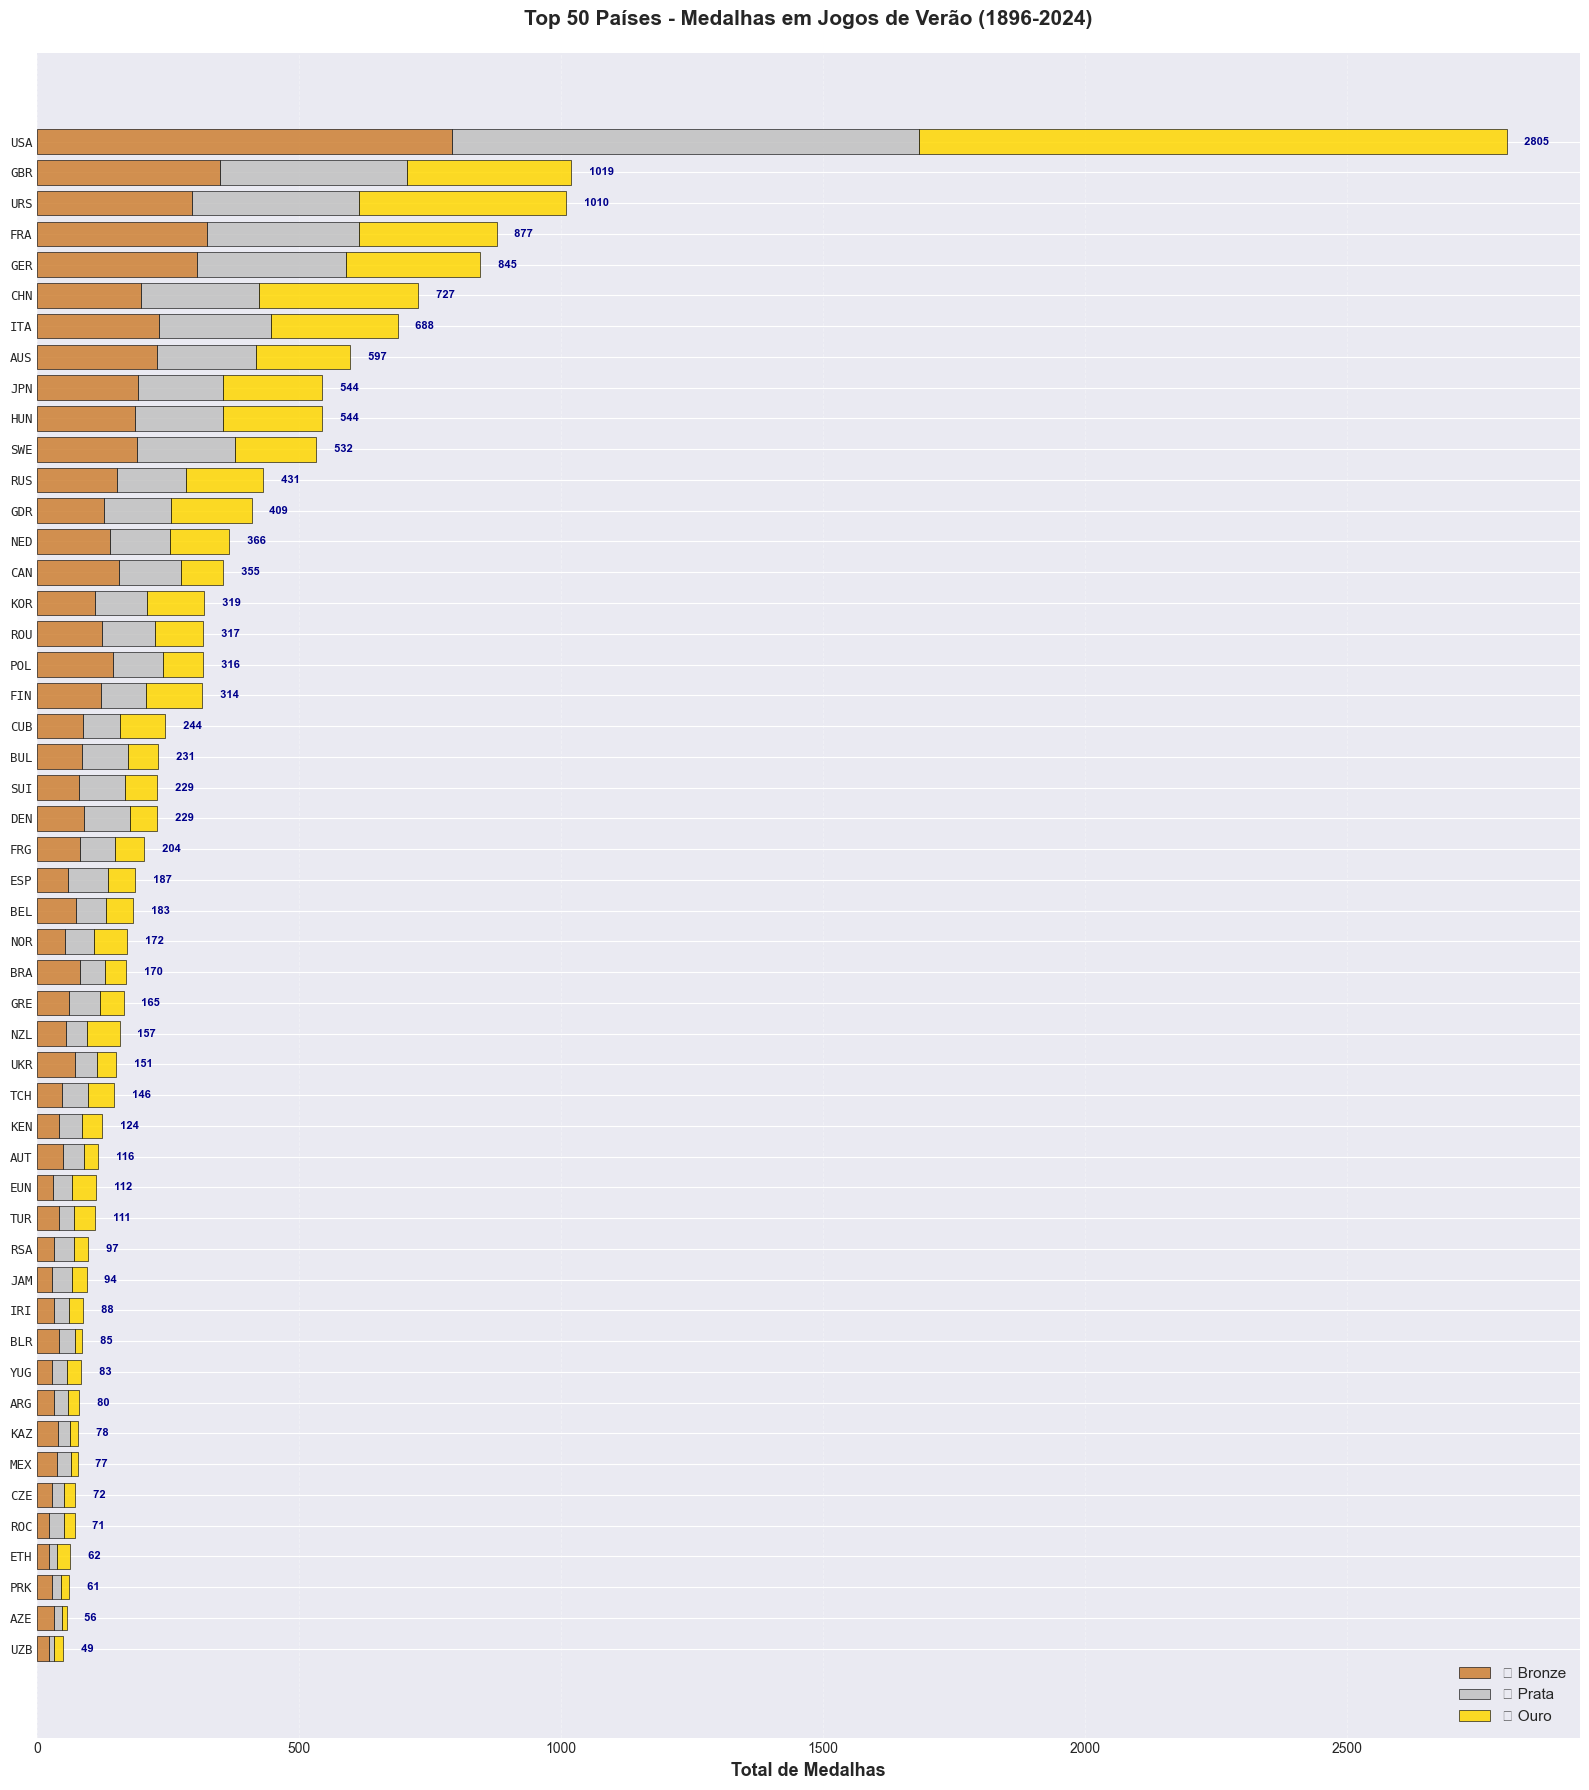

   ✅ top50_summer.png

📊 Gráfico 2: Jogos de Inverno...


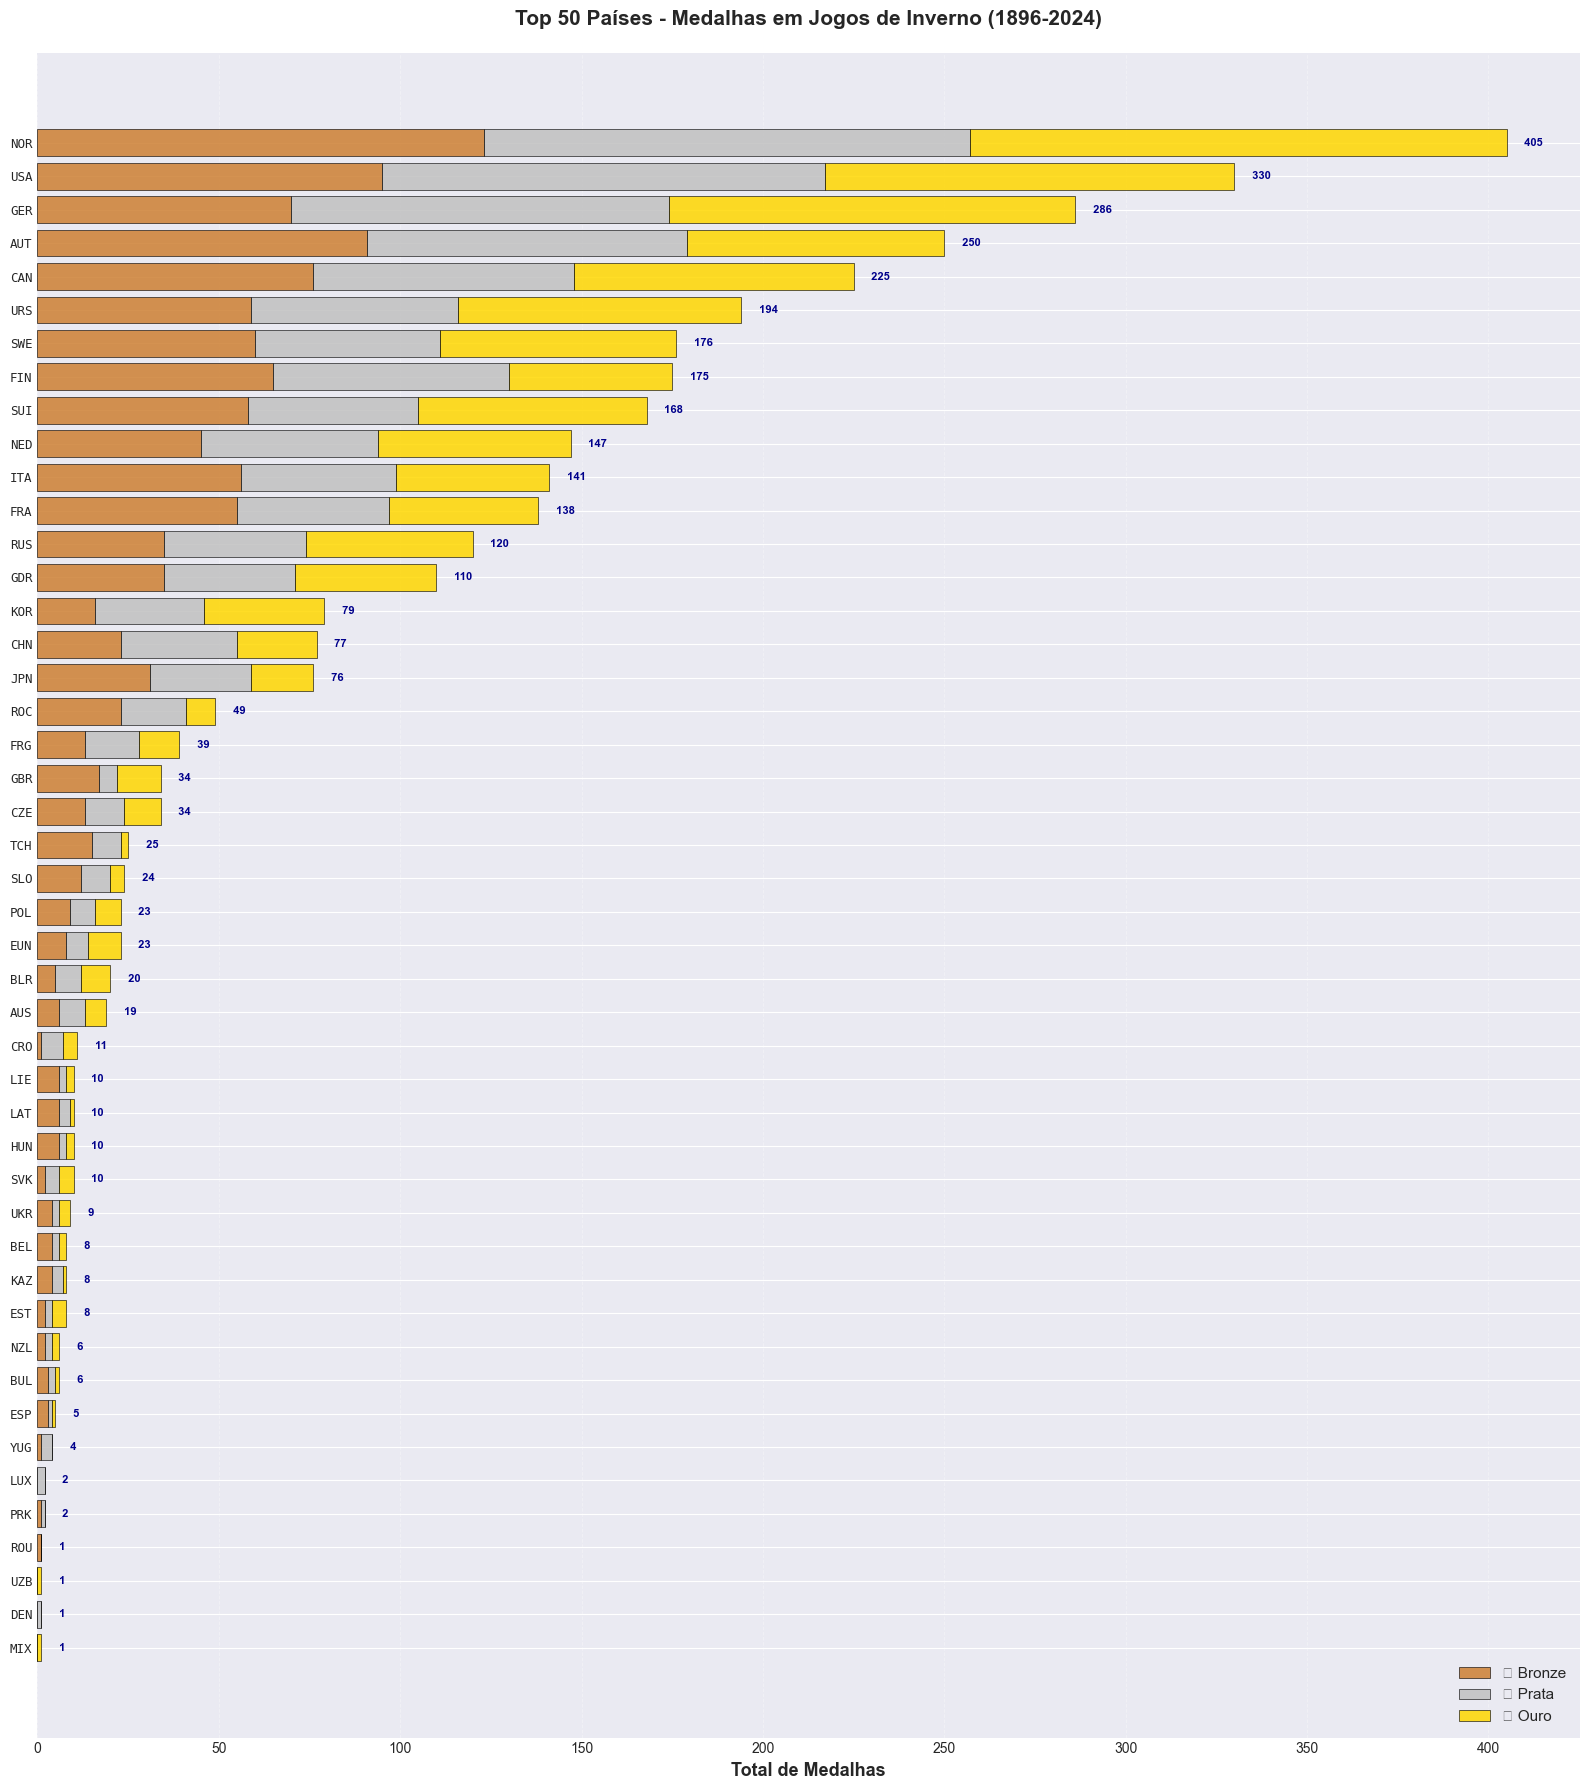

   ✅ top50_winter.png

📊 Gráfico 3: Total Geral...


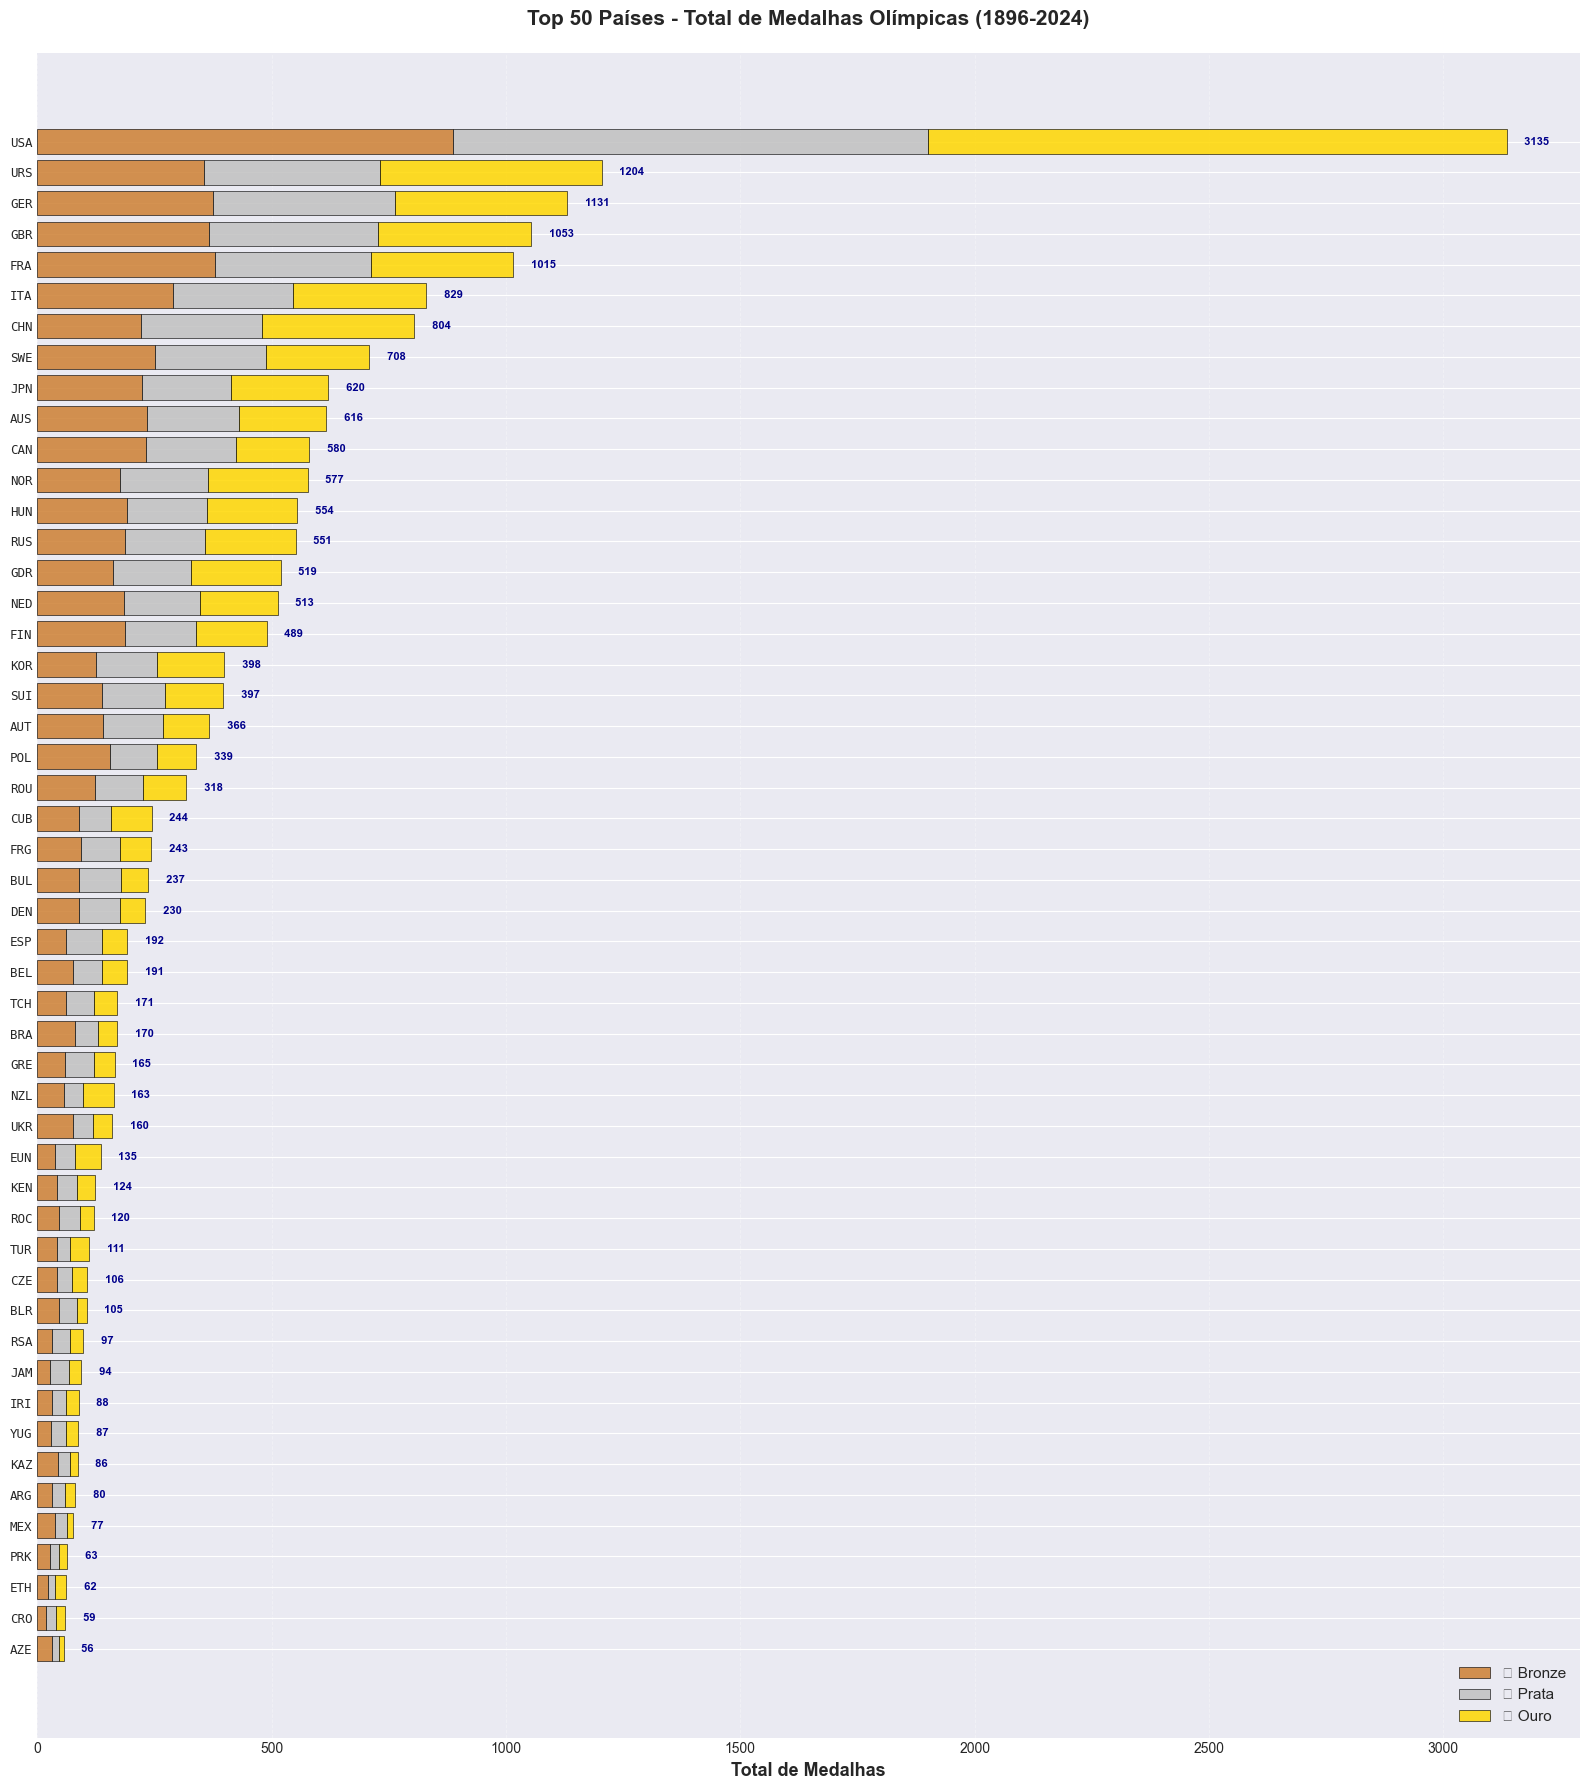

   ✅ top50_total.png

✅ 3 gráficos gerados!


In [19]:
def plot_top50_medals(df, title, filename):
    """Gera gráfico de barras horizontais empilhadas - Top 50"""
    
    # Selecionar Top 50
    df_plot = df.head(50).copy()
    
    # Ordenar para gráfico horizontal (menor no topo)
    df_plot = df_plot.sort_values('total', ascending=True)
    
    # Criar figura
    fig, ax = plt.subplots(figsize=(16, 18))
    
    y_pos = np.arange(len(df_plot))
    
    # Barras empilhadas (Bronze, Prata, Ouro)
    ax.barh(y_pos, df_plot['bronze'], 
           color='#CD7F32', alpha=0.85, label='🥉 Bronze', 
           edgecolor='black', linewidth=0.5)
    
    ax.barh(y_pos, df_plot['silver'], 
           left=df_plot['bronze'],
           color='#C0C0C0', alpha=0.85, label='🥈 Prata',
           edgecolor='black', linewidth=0.5)
    
    ax.barh(y_pos, df_plot['gold'], 
           left=df_plot['bronze'] + df_plot['silver'],
           color='#FFD700', alpha=0.85, label='🥇 Ouro',
           edgecolor='black', linewidth=0.5)
    
    # Configurar eixo Y (países)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['country_noc'], fontsize=9, fontfamily='monospace')
    
    # Configurar eixo X
    ax.set_xlabel('Total de Medalhas', fontsize=13, fontweight='bold')
    
    # Título
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    
    # Legenda
    ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
    
    # Grade
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # Adicionar valores totais
    for i, (idx, row) in enumerate(df_plot.iterrows()):
        total = int(row['total'])
        ax.text(row['total'] + df_plot['total'].max() * 0.01, i, 
               f' {total}',
               va='center', fontsize=8, fontweight='bold', color='darkblue')
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH / 'figures' / filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"   ✅ {filename}")

print("="*100)
print("GERANDO GRÁFICOS TOP 50")
print("="*100)

print("\n📊 Gráfico 1: Jogos de Verão...")
plot_top50_medals(df_summer, 
                 'Top 50 Países - Medalhas em Jogos de Verão (1896-2024)', 
                 'top50_summer.png')

print("\n📊 Gráfico 2: Jogos de Inverno...")
plot_top50_medals(df_winter, 
                 'Top 50 Países - Medalhas em Jogos de Inverno (1896-2024)', 
                 'top50_winter.png')

print("\n📊 Gráfico 3: Total Geral...")
plot_top50_medals(df_total, 
                 'Top 50 Países - Total de Medalhas Olímpicas (1896-2024)', 
                 'top50_total.png')

print("\n" + "="*100)
print("✅ 3 gráficos gerados!")
print("="*100)

---
## 4. Metadados e Documentação

In [20]:
# Criar metadados para cada resultado
datasets = [
    ('medals_summer', 'Medalhas - Jogos de Verão (1896-2024)', df_summer),
    ('medals_winter', 'Medalhas - Jogos de Inverno (1896-2024)', df_winter),
    ('medals_total', 'Medalhas - Total Geral (1896-2024)', df_total)
]

for name, desc, df_data in datasets:
    metadata = {
        'nome': desc,
        'descricao': f'Quadro consolidado de medalhas olímpicas ordenado por total',
        'periodo': '1896-2024',
        'total_paises': len(df_data),
        'total_medalhas': int(df_data['total'].sum()),
        'colunas': list(df_data.columns),
        'fonte': 'Olympedia.org (1896-2022) + Olympics.com (Paris 2024)',
        'notas': 'Dados integrados das fontes oficiais, incluindo tratamento especial para 1956 Equestrian',
        'criado_em': datetime.now().isoformat()
    }
    
    with open(GOLD_PATH / f'{name}_metadata.json', 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    
    print(f"✅ {name}_metadata.json")

print("\n✅ Metadados criados!")

✅ medals_summer_metadata.json
✅ medals_winter_metadata.json
✅ medals_total_metadata.json

✅ Metadados criados!
